# PhillyStat360 — 04f: Per-parcel explanations (TreeSHAP, RF)

Generates per-parcel SHAP values for the top-N flagged parcels so an inspector can see *why* the model flagged a specific address. RF only — the ensemble is dominated by RF and the per-parcel narrative is essentially the same.

**Outputs**
- `data_py/parcel_shap_topflags.csv` — one row per parcel × top-5 contributing features
- `graphs/python/shap_summary_topflags.png` — global mean(|SHAP|) summary


## 0. Setup

In [1]:
# Mount Drive in Colab; pass through locally.
try:
    from google.colab import drive
    drive.mount('/content/drive')
    IN_COLAB = True
except ImportError:
    IN_COLAB = False
    print('Not in Colab — using local paths.')


Mounted at /content/drive


In [2]:
from pathlib import Path

if IN_COLAB:
    ROOT = Path('/content/drive/MyDrive/PhillyStat_R/PhillyStat360')
else:
    ROOT = Path('G:/My Drive/PhillyStat_R/PhillyStat360')

RAW_PATH   = ROOT / 'rawdata'
DATA_PATH  = ROOT / 'data'
PY_PATH    = ROOT / 'data_py'
OUT_PATH   = ROOT / 'data_py'
GRAPH_PATH = ROOT / 'graphs' / 'python'
OUT_PATH.mkdir(parents=True, exist_ok=True)
GRAPH_PATH.mkdir(parents=True, exist_ok=True)
print('ROOT =', ROOT)


ROOT = /content/drive/MyDrive/PhillyStat_R/PhillyStat360


In [3]:
import warnings, numpy as np, pandas as pd
import matplotlib.pyplot as plt, seaborn as sns
warnings.filterwarnings('ignore', category=UserWarning)
sns.set_theme(style='whitegrid', context='talk')
SEED = 42

import joblib
# `pip install shap` if not already
try:
    import shap
except ImportError:
    !pip install -q shap
    import shap


## 1. Load model, feature matrix, predictions

In [4]:
rf = joblib.load(PY_PATH / 'model_rf_final.joblib')
feat_full = pd.read_csv(DATA_PATH / 'features_residential.csv', low_memory=False)
feat_full['parcel_number'] = feat_full['parcel_number'].astype(str).str.strip()

X_cols = list(rf.feature_names_in_)
print(f'Features used: {len(X_cols)}')
X = feat_full[['parcel_number'] + X_cols].copy()

preds = pd.read_csv(PY_PATH / 'predictions_04b.csv', low_memory=False)
preds['parcel_number'] = preds['parcel_number'].astype(str).str.strip()


Features used: 34


## 2. Pick the top-N flagged parcels

In [5]:
TOP_N = 200  # how many parcels to explain in detail
top_parcels = (
    preds.sort_values('ensemble_prob', ascending=False)
         .head(TOP_N)
         .merge(X, on='parcel_number', how='left')
)
print(f'Pulled feature rows for top-{TOP_N} flagged parcels.')


Pulled feature rows for top-200 flagged parcels.


## 3. Apply the pipeline up to (but not including) the RF, then TreeSHAP

The RF pipeline is `impute → variance_threshold → rf`. SHAP needs the same matrix the tree saw.

In [6]:
imputer = rf.named_steps['impute']
vt      = rf.named_steps['vt']
clf     = rf.named_steps['rf']

X_top = top_parcels[X_cols].values
X_imp = imputer.transform(X_top)
X_vt  = vt.transform(X_imp)
post_vt_names = [n for n, k in zip(X_cols, vt.get_support()) if k]

explainer = shap.TreeExplainer(clf)
shap_vals = explainer.shap_values(X_vt)
# binary RF returns [class0, class1] — take class 1
if isinstance(shap_vals, list):
    shap_vals = shap_vals[1]
elif shap_vals.ndim == 3:
    shap_vals = shap_vals[:, :, 1]
print('SHAP matrix shape:', shap_vals.shape)


SHAP matrix shape: (200, 34)


## 4. Tidy per-parcel explanation table

In [7]:
rows = []
for i, row in top_parcels.reset_index(drop=True).iterrows():
    contribs = pd.DataFrame({'feature': post_vt_names,
                             'value':   X_vt[i],
                             'shap':    shap_vals[i]})
    contribs['abs_shap'] = contribs['shap'].abs()
    contribs = contribs.sort_values('abs_shap', ascending=False).head(5)
    for r in contribs.itertuples():
        rows.append({
            'parcel_number': row['parcel_number'],
            'ensemble_prob': row['ensemble_prob'],
            'ovs':           row['ovs'],
            'feature':       r.feature,
            'value':         r.value,
            'shap':          r.shap,
            'direction':     'pushed up' if r.shap > 0 else 'pushed down',
        })
out = pd.DataFrame(rows)
out.to_csv(OUT_PATH / 'parcel_shap_topflags.csv', index=False)
print(f'Wrote {len(out):,} rows to {OUT_PATH / "parcel_shap_topflags.csv"}')
out.head(15).round(4)


Wrote 1,000 rows to /content/drive/MyDrive/PhillyStat_R/PhillyStat360/data_py/parcel_shap_topflags.csv


,parcel_number,ensemble_prob,ovs,feature,value,shap,direction
0,491388300,1.0,1,days_since_last_cs,441.0,0.2251,pushed up
1,491388300,1.0,1,n_cs_total,3.0,0.1032,pushed up
2,491388300,1.0,1,days_since_last_viol,441.0,0.0575,pushed up
3,491388300,1.0,1,n_violations_5yr,10.0,0.0537,pushed up
4,491388300,1.0,1,n_violations_3yr,4.0,0.0356,pushed up
5,463222900,1.0,1,nbr_n_vacant_zip,515.0,-0.3191,pushed down
6,463222900,1.0,1,days_since_last_cs,532.0,0.1987,pushed up
7,463222900,1.0,1,n_cs_total,2.0,0.0807,pushed up
8,463222900,1.0,1,n_violations_5yr,5.0,0.0387,pushed up
9,463222900,1.0,1,n_violations_3yr,5.0,0.0323,pushed up


## 5. Global summary across the top-N

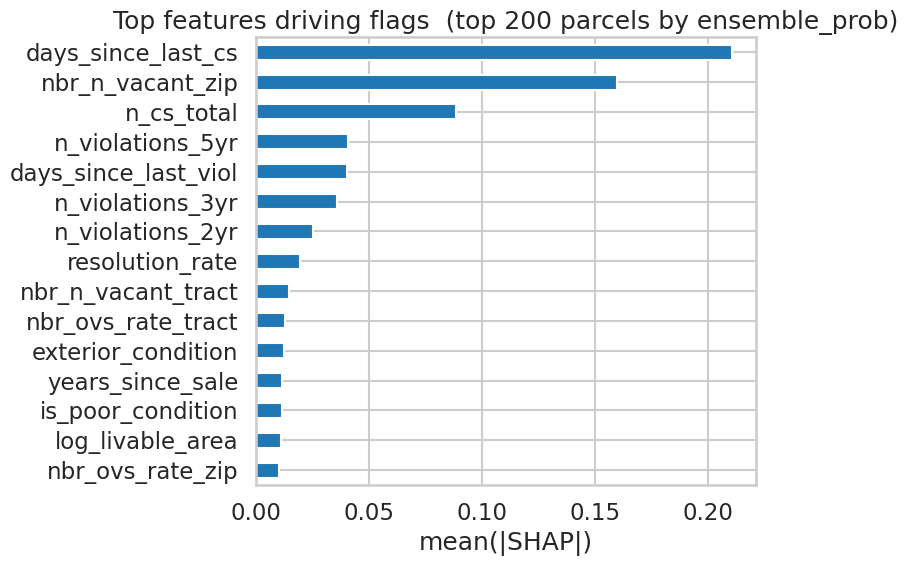

In [8]:
mean_abs = pd.Series(np.abs(shap_vals).mean(axis=0), index=post_vt_names) \
              .sort_values(ascending=False).head(15)
fig, ax = plt.subplots(figsize=(8, 6))
mean_abs[::-1].plot(kind='barh', color='#1f77b4', ax=ax)
ax.set_xlabel('mean(|SHAP|)')
ax.set_title(f'Top features driving flags  (top {TOP_N} parcels by ensemble_prob)')
plt.tight_layout()
plt.savefig(GRAPH_PATH / 'shap_summary_topflags.png', dpi=200, bbox_inches='tight')
plt.show()


---
**Done.** `parcel_shap_topflags.csv` is the inspector-facing artifact: 5 reasons per parcel.

In [9]:
!jupyter nbconvert --to html /content/drive/MyDrive/PhillyStat_R/PhillyStat360/code/python/04f_local_explanations.ipynb

[NbConvertApp] Converting notebook /content/drive/MyDrive/PhillyStat_R/PhillyStat360/code/python/04f_local_explanations.ipynb to html
[NbConvertApp] Writing 309980 bytes to /content/drive/MyDrive/PhillyStat_R/PhillyStat360/code/python/04f_local_explanations.html
